# Travel API Performance Monitoring

This project analyzes the performance of travel booking APIs for a mid-size travel agency.

We use 3 months of request/response logs with the following fields:

- `timestamp`: date & time of the request  
- `request_id`: unique request identifier  
- `agency`: client (Revolut, Hopper, Snap, etc.)  
- `provider`: hotel provider (Hotelbeds, Agoda, GOGlobal, Expedia, DOTW, …)  
- `flow_type`: Prebook / Book / Valuation  
- `status_code`: HTTP status code (200, 201, 4xx, 5xx…)  
- `error_category`: type of error (Timeout, Availability Error, Rate Limit, etc.)  
- `response_time_seconds`: API response time  
- `result`: SUCCESS or ERROR  

**Goals:**

1. Monitor error rates by provider, agency, and flow  
2. Track response times  
3. Detect anomalies (spikes in errors or latency)  
4. Produce business & optimization insights for account management
```



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [3]:
file_path = "/content/travel_api_logs_last_3_months.csv - Feuille 1.csv"  # change if needed

df = pd.read_csv(file_path)
df.head()



,timestamp,request_id,agency,provider,flow_type,status_code,error_category,response_time_seconds,result
0,06/12/2025 16:02:47,REQ-921345671,Revolut,Hotelbeds,Prebook,200,NaN,1.23,SUCCESS
1,05/12/2025 16:02:47,REQ-921345672,Revolut,Hotelbeds,Book,500,Upstream Error,3.85,ERROR
2,04/12/2025 16:02:47,REQ-921345673,Hopper,Agoda,Valuation,200,NaN,1.87,SUCCESS
3,03/12/2025 16:02:47,REQ-921345674,Snap,GOGlobal,Prebook,408,Timeout,4.12,ERROR
4,02/12/2025 16:02:47,REQ-921345675,Traveloka,Expedia,Book,201,NaN,0.98,SUCCESS


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

df.head()


,timestamp,request_id,agency,provider,flow_type,status_code,error_category,response_time_seconds,result,date,hour,day_of_week
0,2025-06-12 16:02:47,REQ-921345671,Revolut,Hotelbeds,Prebook,200,NaN,1.23,SUCCESS,2025-06-12,16.0,Thursday
1,2025-05-12 16:02:47,REQ-921345672,Revolut,Hotelbeds,Book,500,Upstream Error,3.85,ERROR,2025-05-12,16.0,Monday
2,2025-04-12 16:02:47,REQ-921345673,Hopper,Agoda,Valuation,200,NaN,1.87,SUCCESS,2025-04-12,16.0,Saturday
3,2025-03-12 16:02:47,REQ-921345674,Snap,GOGlobal,Prebook,408,Timeout,4.12,ERROR,2025-03-12,16.0,Wednesday
4,2025-02-12 16:02:47,REQ-921345675,Traveloka,Expedia,Book,201,NaN,0.98,SUCCESS,2025-02-12,16.0,Wednesday


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nResult distribution:")
print(df["result"].value_counts(normalize=True).round(3))

print("\nStatus code distribution:")
print(df["status_code"].value_counts().head(10))

print("\nSample of errors:")
df[df["result"] == "ERROR"].head()


Shape: (234, 12)

Columns: ['timestamp', 'request_id', 'agency', 'provider', 'flow_type', 'status_code', 'error_category', 'response_time_seconds', 'result', 'date', 'hour', 'day_of_week']

Result distribution:
result
SUCCESS    0.526
ERROR      0.474
Name: proportion, dtype: float64

Status code distribution:
status_code
200    98
500    25
408    25
201    25
403    25
429    24
502    12
Name: count, dtype: int64

Sample of errors:


,timestamp,request_id,agency,provider,flow_type,status_code,error_category,response_time_seconds,result,date,hour,day_of_week
1,2025-05-12 16:02:47,REQ-921345672,Revolut,Hotelbeds,Book,500,Upstream Error,3.85,ERROR,2025-05-12,16.0,Monday
3,2025-03-12 16:02:47,REQ-921345674,Snap,GOGlobal,Prebook,408,Timeout,4.12,ERROR,2025-03-12,16.0,Wednesday
5,2025-01-12 16:02:47,REQ-921345676,BookingPartner,DOTW,Prebook,403,Authentication Failed,2.14,ERROR,2025-01-12,16.0,Sunday
7,NaT,REQ-921345678,Hopper,Expedia,Book,429,Rate Limit,3.55,ERROR,NaT,NaN,NaN
9,NaT,REQ-921345680,Traveloka,Hotelbeds,Book,502,Upstream Error,4.20,ERROR,NaT,NaN,NaN


In [6]:
daily = (
    df.groupby("date")
      .agg(
          total_requests=("request_id", "count"),
          total_errors=("result", lambda x: (x == "ERROR").sum()),
          avg_response_time=("response_time_seconds", "mean")
      )
      .reset_index()
)

daily["error_rate_pct"] = (daily["total_errors"] / daily["total_requests"]) * 100
daily.head()


,date,total_requests,total_errors,avg_response_time,error_rate_pct
0,2025-01-05,1,0,1.23,0.0
1,2025-01-06,1,1,3.55,100.0
2,2025-01-07,1,0,1.11,0.0
3,2025-01-08,1,1,4.12,100.0
4,2025-01-09,1,1,3.85,100.0


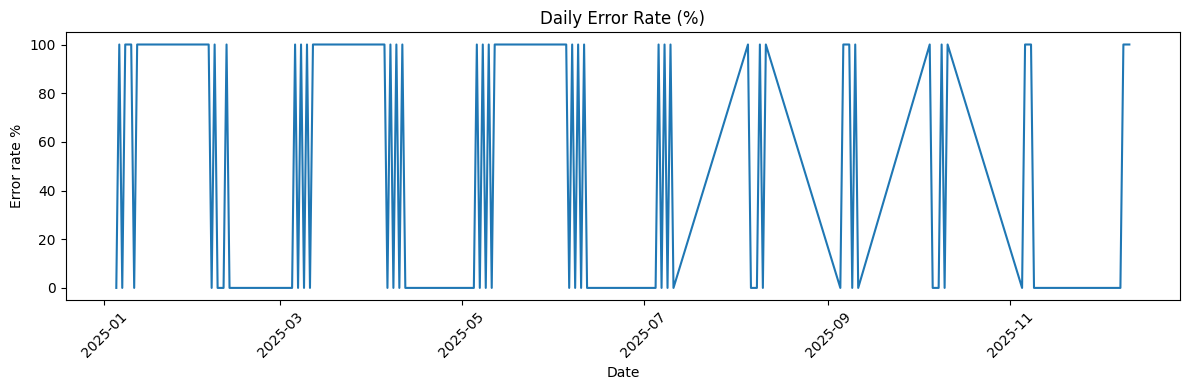

In [7]:
plt.figure(figsize=(12,4))
plt.plot(daily["date"], daily["error_rate_pct"])
plt.title("Daily Error Rate (%)")
plt.xlabel("Date")
plt.ylabel("Error rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


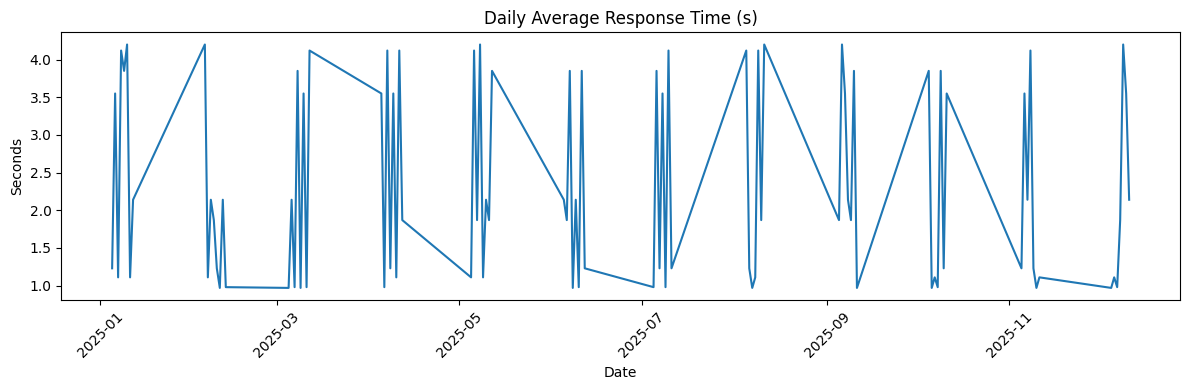

In [8]:
plt.figure(figsize=(12,4))
plt.plot(daily["date"], daily["avg_response_time"])
plt.title("Daily Average Response Time (s)")
plt.xlabel("Date")
plt.ylabel("Seconds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
provider_stats = (
    df.groupby("provider")
      .agg(
          total_requests=("request_id", "count"),
          total_errors=("result", lambda x: (x == "ERROR").sum()),
          avg_response_time=("response_time_seconds", "mean")
      )
      .reset_index()
)

provider_stats["error_rate_pct"] = (
    provider_stats["total_errors"] / provider_stats["total_requests"] * 100
)

provider_stats.sort_values("error_rate_pct", ascending=False).head(10)
provider_stats = provider_stats.sort_values(by="error_rate_pct", ascending=False).reset_index(drop=True)

provider_stats.index = provider_stats.index + 1

provider_stats



,provider,total_requests,total_errors,avg_response_time,error_rate_pct
1,DOTW,25,25,2.140000,100.000000
2,Hotelbeds,62,37,2.861290,59.677419
3,GOGlobal,49,25,2.577143,51.020408
4,Expedia,49,24,2.238776,48.979592
5,Agoda,49,0,1.497755,0.000000


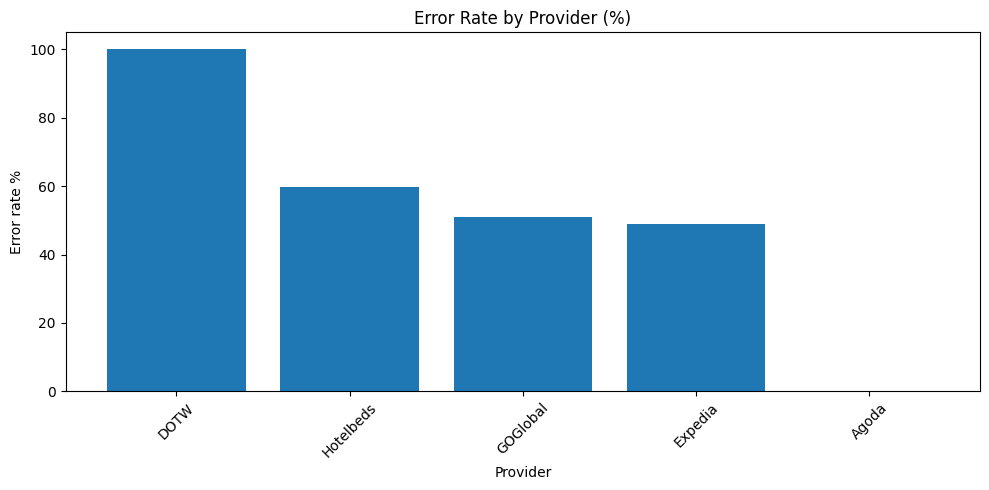

In [11]:
top_providers = provider_stats.sort_values("error_rate_pct", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(top_providers["provider"], top_providers["error_rate_pct"])
plt.title("Error Rate by Provider (%)")
plt.xlabel("Provider")
plt.ylabel("Error rate %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
agency_flow = (
    df.groupby(["agency", "flow_type"])
      .agg(
          total_requests=("request_id", "count"),
          total_errors=("result", lambda x: (x == "ERROR").sum()),
          avg_response_time=("response_time_seconds", "mean")
      )
      .reset_index()
)

agency_flow["error_rate_pct"] = (
    agency_flow["total_errors"] / agency_flow["total_requests"] * 100
)

agency_flow.sort_values(["agency", "flow_type"])


,agency,flow_type,total_requests,total_errors,avg_response_time,error_rate_pct
0,BookingPartner,Prebook,25,25,2.140000,100.000000
1,Hopper,Book,24,24,3.550000,100.000000
2,Hopper,Valuation,25,0,1.870000,0.000000
3,Revolut,Book,25,25,3.850000,100.000000
4,Revolut,Prebook,25,0,1.230000,0.000000
5,Revolut,Valuation,24,0,1.110000,0.000000
6,Snap,Prebook,49,25,2.577143,51.020408
7,Traveloka,Book,37,12,2.024324,32.432432


In [14]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.dropna(subset=["date"])

latest_date = df["date"].max()
print("Latest date in file:", latest_date)

latest_df = df[df["date"] == latest_date]

latest_df.head()


Latest date in file: 2025-12-11 00:00:00


,timestamp,request_id,agency,provider,flow_type,status_code,error_category,response_time_seconds,result,date,hour,day_of_week
24,2025-12-11 16:02:47,REQ-921345676,BookingPartner,DOTW,Prebook,403,Authentication Failed,2.14,ERROR,2025-12-11,16.0,Thursday


In [18]:
provider_summary = (
    df.groupby("provider")
      .agg(
          total_requests=("status_code", "count"),
          total_errors=("result", lambda x: (x == "ERROR").sum()),
          avg_response_time=("response_time_seconds", "mean")
      )
      .reset_index()
)

provider_summary["error_rate_pct"] = (
    provider_summary["total_errors"] / provider_summary["total_requests"] * 100
)

alerts = provider_summary[provider_summary["error_rate_pct"] > 10]
alerts




,provider,total_requests,total_errors,avg_response_time,error_rate_pct
1,DOTW,10,10,2.140,100.0
2,Expedia,18,9,2.265,50.0
3,GOGlobal,18,9,2.545,50.0
4,Hotelbeds,25,15,2.886,60.0


In [19]:
daily.to_csv("kpi_daily_travel_api.csv", index=False)
provider_stats.to_csv("kpi_provider_travel_api.csv", index=False)
agency_flow.to_csv("kpi_agency_flow_travel_api.csv", index=False)
